# 04 - Feature Engineering

Builds business-meaningful derived features on top of the cleaned dataset and validates that each one carries real signal.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import config
from data_loader import load_csv, save_csv
from feature_engineering import engineer_features

df = load_csv(config.CLEAN_DATA_PATH)
feat = engineer_features(df)
print('Before:', df.shape, '-> After:', feat.shape)
new_cols = [c for c in feat.columns if c not in df.columns]
print('New features:', new_cols)

2026-07-07 08:12:56,156 | INFO | Loaded customer_churn_clean.csv: 7500 rows x 30 columns


Before: (7500, 30) -> After: (7500, 39)
New features: ['TenureGroup', 'MonthlySpendCategory', 'HighValueCustomer', 'LongTermCustomer', 'ServiceCount', 'AvgMonthlyRevenue', 'ComplaintFrequency', 'EngagementScore', 'RiskScore']


## TenureGroup — non-linear tenure risk buckets

In [2]:
tab = feat.groupby('TenureGroup', observed=True)['Churn'].apply(lambda s: (s=='Yes').mean()*100)
print(tab.round(1))

TenureGroup
0-6 Months      51.2
7-12 Months     43.3
13-24 Months    34.8
25-48 Months    24.9
49+ Months      19.5
Name: Churn, dtype: float64


## RiskScore — explainable 0-100 heuristic score

Churn
No     16.1
Yes    33.3
Name: RiskScore, dtype: float64


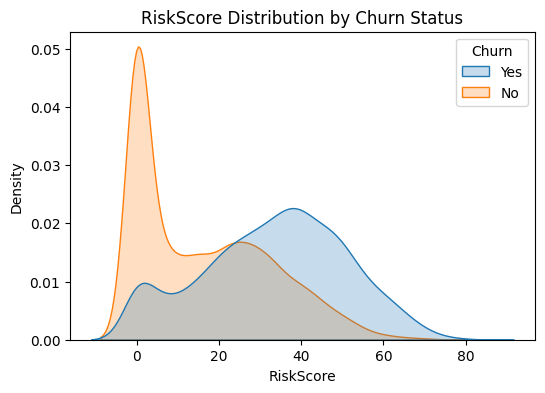

In [3]:
print(feat.groupby('Churn')['RiskScore'].mean().round(1))
fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(data=feat, x='RiskScore', hue='Churn', fill=True, common_norm=False, ax=ax)
ax.set_title('RiskScore Distribution by Churn Status'); plt.show()

**Validation:** Churned customers average a RiskScore of **33.3** vs **16.1** for retained customers — strong separation confirms this composite heuristic (built purely from known churn drivers, no ML) is genuinely useful as a fast, explainable pre-model screen.

## EngagementScore — composite loyalty signal

In [4]:
print(feat.groupby('Churn')['EngagementScore'].mean().round(1))

Churn
No     50.9
Yes    43.7
Name: EngagementScore, dtype: float64


**Validation:** Retained customers average **50.9** vs **43.7** for churned — confirms the score (referrals + satisfaction - complaints) captures loyalty as intended.

## ServiceCount — bundling / switching-friction proxy

In [5]:
print(feat.groupby('ServiceCount')['Churn'].apply(lambda s: (s=='Yes').mean()*100).round(1))

ServiceCount
0    17.2
1    22.3
2    35.9
3    37.3
4    33.9
5    33.9
6    37.9
7    40.0
Name: Churn, dtype: float64


## AvgMonthlyRevenue — normalized spend rate (fixes Tenure/TotalCharges collinearity)

In [6]:
print(feat[['TotalCharges','Tenure','AvgMonthlyRevenue','MonthlyCharges']].corr().round(2))

                   TotalCharges  Tenure  AvgMonthlyRevenue  MonthlyCharges
TotalCharges               1.00    0.84               0.48            0.45
Tenure                     0.84    1.00               0.07            0.01
AvgMonthlyRevenue          0.48    0.07               1.00            0.93
MonthlyCharges             0.45    0.01               0.93            1.00


**Note:** `AvgMonthlyRevenue` correlates far less with `Tenure` than `TotalCharges` does, which is exactly why it was engineered — it gives the model a spend-rate signal independent of how long the customer has been around.

## HighValueCustomer & LongTermCustomer flags

In [7]:
print('HighValueCustomer churn rate:', feat.groupby('HighValueCustomer')['Churn'].apply(lambda s:(s=='Yes').mean()*100).round(1).to_dict())
print('LongTermCustomer churn rate:', feat.groupby('LongTermCustomer')['Churn'].apply(lambda s:(s=='Yes').mean()*100).round(1).to_dict())

HighValueCustomer churn rate: {0: 32.6, 1: 29.3}
LongTermCustomer churn rate: {0: 41.9, 1: 23.2}


In [8]:
save_csv(feat, config.FEATURED_DATA_PATH)
feat.head()

2026-07-07 08:12:57,784 | INFO | Saved customer_churn_features.csv: 7500 rows x 39 columns


,CustomerID,Gender,Age,SeniorCitizen,MaritalStatus,Dependents,Tenure,ContractType,InternetService,PhoneService,...,CustomerLifetimeValue_Outlier,TenureGroup,MonthlySpendCategory,HighValueCustomer,LongTermCustomer,ServiceCount,AvgMonthlyRevenue,ComplaintFrequency,EngagementScore,RiskScore
0,CUST-100000,Female,40,0,Married,Yes,22,Month-to-Month,Fiber Optic,No,...,0,13-24 Months,Premium,0,0,1,83.310909,0.545455,35,41.7
1,CUST-100001,Male,23,0,Married,Yes,43,Month-to-Month,No,No,...,0,25-48 Months,Budget,0,1,0,23.156512,0.279070,65,22.7
2,CUST-100002,Female,38,0,Widowed,No,28,Month-to-Month,DSL,Yes,...,0,25-48 Months,Premium,0,1,2,70.191071,0.000000,45,21.7
3,CUST-100003,Female,27,0,Married,No,1,Month-to-Month,Fiber Optic,Yes,...,0,0-6 Months,Premium,0,0,2,94.910000,12.000000,50,54.7
4,CUST-100004,Male,37,0,Single,Yes,0,Month-to-Month,No,Yes,...,0,0-6 Months,Budget,0,0,1,0.000000,24.000000,25,52.0
